# How Listening Behavior Shapes Playlists: A Data Analytics Approach to Music Personalization

## 🧠 Problem Statement

### Platforms like Spotify create playlists that feel highly personalized.
### But how does this actually work?

### This project simulates how user listening behavior over time can be used to:

#### - Identify preferences
#### - Detect patterns
#### - Generate curated playlists

## 🎯 Objective
#### - Simulate user listening data
#### - Identify user preferences (genres, patterns)
#### - Build a simple playlist generator
#### - Understand how personalization works

## 🔍 Introduction

### Music platforms personalize playlists by analyzing user behavior over time.

### This project demonstrates how listening patterns such as genre preference and time of day can be used to generate curated playlists using simple data analytics techniques.

In [12]:
import pandas as pd
import numpy as np

## 🧩 Step 1: Simulating User Listening Data

### A dataset is created to represent user listening behavior, including:
#### - User ID  
#### - Song and artist  
#### - Genre  
#### - Time of listening  
#### - Number of listens  

#### This simulates how platforms track user activity.

In [13]:
import random
import pandas as pd

# Set a seed so the random output stays the same each time
random.seed(42)

# 1. Create users and songs
users = [f"U{i}" for i in range(1, 51)]
songs = [f"Song{i}" for i in range(1, 21)]

# 2. Genre options
genres = ["Pop", "Hip-Hop", "Rock", "Indie", "EDM"]

# 3. Time of day categories
time_of_day_options = ["Morning", "Afternoon", "Evening", "Night"]

# Some simple words to create random artist names
first_words = ["Neon", "Silver", "Golden", "Midnight", "Velvet", "Electric", "Crimson", "Echo", "Lunar", "Wild"]
second_words = ["Beats", "Pulse", "Dreams", "Waves", "Rhythm", "Lights", "Notes", "Sound", "Vibes", "Groove"]

# Assign each song a random genre and random artist
used_artist_names = set()
song_details = {}

for song in songs:
    # Keep generating until we get a unique artist name
    while True:
        artist_name = f"{random.choice(first_words)} {random.choice(second_words)}"
        if artist_name not in used_artist_names:
            used_artist_names.add(artist_name)
            break

    song_details[song] = {
        "artist": artist_name,
        "genre": random.choice(genres)
    }

# 4. Generate listening events
rows = []

for user in users:
    # Each user listens to 10 to 20 songs
    listened_songs = random.sample(songs, random.randint(10, 20))

    for song in listened_songs:
        rows.append({
            "user_id": user,
            "song": song,
            "artist": song_details[song]["artist"],
            "genre": song_details[song]["genre"],
            "time_of_day": random.choice(time_of_day_options),
            "listen_count": random.randint(1, 10)
        })

# 5. Store in dataframe df
df = pd.DataFrame(rows)

# 6. Print shape and first 10 rows
print("df shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))


df shape: (733, 6)

First 10 rows:
  user_id    song           artist    genre time_of_day  listen_count
0      U1   Song9      Echo Groove     Rock     Evening             9
1      U1  Song15     Velvet Beats    Indie   Afternoon             6
2      U1  Song12  Midnight Lights      Pop     Morning             4
3      U1   Song6   Midnight Vibes      EDM     Morning             6
4      U1  Song18       Wild Waves      Pop       Night             5
5      U1  Song17    Velvet Groove     Rock     Morning             4
6      U1   Song4       Wild Notes      Pop     Evening             4
7      U1  Song11  Electric Rhythm  Hip-Hop       Night             7
8      U1   Song5       Neon Pulse  Hip-Hop       Night             3
9      U1  Song13     Silver Notes      Pop     Evening             3


## 📊 Data Overview

### Each row represents a listening event.

#### - user_id → unique user  
#### - song → track listened to  
#### - genre → music category  
#### - time_of_day → when the song was played  
#### - listen_count → frequency of listening  

## 🧠 Step 2: Identifying User Preferences

### User preferences are determined by analyzing listening frequency across genres.

### The most frequently listened genre is considered the user’s primary interest.

In [14]:
# 1. Group df by user_id and genre
# 2. Sum listen_count
genre_summary = df.groupby(["user_id", "genre"], as_index=False)["listen_count"].sum()

# 3. For each user, find the genre with the highest total listen_count
top_genre_idx = genre_summary.groupby("user_id")["listen_count"].idxmax()

# 4. Create user_profile dataframe
user_profile = genre_summary.loc[top_genre_idx, ["user_id", "genre"]].rename(
    columns={"genre": "top_genre"}
)

# Reset index for a clean dataframe
user_profile = user_profile.reset_index(drop=True)

# 5. Show first 10 rows
print(user_profile.head(10))


  user_id top_genre
0      U1       Pop
1     U10       Pop
2     U11       Pop
3     U12       Pop
4     U13       Pop
5     U14      Rock
6     U15       Pop
7     U16   Hip-Hop
8     U17       Pop
9     U18       Pop


### 💡 Insight

#### Users tend to repeatedly listen to specific genres, allowing platforms to build strong preference profiles over time.

## 🎯 Step 3: Playlist Generation

### Playlists are generated by selecting songs from a user’s preferred genre.

### Songs are ranked based on listening frequency to ensure relevance.

In [15]:
def generate_playlist(user_id):
    # Get the user's top genre from user_profile
    top_genre_row = user_profile[user_profile["user_id"] == user_id]

    if top_genre_row.empty:
        print(f"No profile found for {user_id}")
        return pd.DataFrame()

    top_genre = top_genre_row["top_genre"].values[0]

    # Filter songs from df that match the user's top genre
    genre_songs = df[df["genre"] == top_genre]

    # Sort by listen_count in descending order
    genre_songs = genre_songs.sort_values(by="listen_count", ascending=False)

    # Return top 5 unique songs
    top_5_songs = genre_songs[["song", "artist", "genre", "listen_count"]].drop_duplicates(subset="song").head(5)

    return top_5_songs


# Test for 2 users
print("Playlist for U1:")
print(generate_playlist("U1"))

print("\nPlaylist for U2:")
print(generate_playlist("U2"))


Playlist for U1:
       song        artist genre  listen_count
728   Song4    Wild Notes   Pop            10
326   Song3  Silver Vibes   Pop            10
136  Song18    Wild Waves   Pop            10
634  Song20  Silver Waves   Pop            10
257  Song13  Silver Notes   Pop            10

Playlist for U2:
       song        artist  genre  listen_count
731  Song16   Lunar Pulse  Indie            10
569  Song10   Neon Dreams  Indie            10
313  Song15  Velvet Beats  Indie            10


## 🔄 Step 4: Time-Based Personalization

### Listening behavior varies across time of day.

### Playlists are refined by considering both:
#### - Preferred genre  
#### - Time of listening  

### This creates more context-aware recommendations.

In [16]:
def generate_playlist(user_id, time_of_day):
    # Get the user's top genre
    user_row = user_profile[user_profile["user_id"] == user_id]

    if user_row.empty:
        print(f"No profile found for {user_id}")
        return pd.DataFrame()

    top_genre = user_row["top_genre"].iloc[0]

    # Filter songs by genre and time of day
    filtered_songs = df[
        (df["genre"] == top_genre) & (df["time_of_day"] == time_of_day)
    ]

    if filtered_songs.empty:
        print(f"No songs found for {user_id} in {time_of_day}")
        return pd.DataFrame()

    # Sort by listen_count in descending order
    filtered_songs = filtered_songs.sort_values(by="listen_count", ascending=False)

    # Return top 5 unique songs
    top_5_songs = filtered_songs[
        ["song", "artist", "genre", "time_of_day", "listen_count"]
    ].drop_duplicates(subset="song").head(5)

    return top_5_songs


# Test: Morning playlist
print("Morning playlist for U1:")
print(generate_playlist("U1", "Morning"))

# Test: Night playlist
print("\nNight playlist for U1:")
print(generate_playlist("U1", "Night"))


Morning playlist for U1:
       song           artist genre time_of_day  listen_count
248   Song4       Wild Notes   Pop     Morning            10
634  Song20     Silver Waves   Pop     Morning            10
398  Song18       Wild Waves   Pop     Morning            10
551  Song13     Silver Notes   Pop     Morning            10
712  Song12  Midnight Lights   Pop     Morning             9

Night playlist for U1:
       song           artist genre time_of_day  listen_count
728   Song4       Wild Notes   Pop       Night            10
513  Song12  Midnight Lights   Pop       Night            10
136  Song18       Wild Waves   Pop       Night            10
532  Song20     Silver Waves   Pop       Night             9
90    Song3     Silver Vibes   Pop       Night             9


## 📈 Listening Patterns

### The visualization shows how listening activity is distributed across genres.

### This helps identify dominant preferences that influence playlist recommendations.

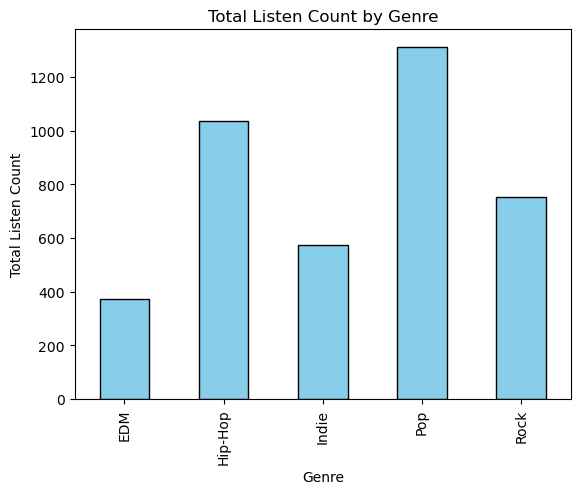

In [17]:
import matplotlib.pyplot as plt

# 1. Count total listen_count per genre
genre_listens = df.groupby("genre")["listen_count"].sum()

# 2. Plot a bar chart
genre_listens.plot(kind="bar", color="skyblue", edgecolor="black")

# 3. Label axes and title clearly
plt.xlabel("Genre")
plt.ylabel("Total Listen Count")
plt.title("Total Listen Count by Genre")

plt.show()


### 📈 Observation

#### Certain genres dominate listening behavior, which directly influences playlist recommendations.

genre        EDM  Hip-Hop  Indie  Pop  Rock
time_of_day                                
Morning       21       40     23   49    37
Afternoon     16       53     25   48    26
Evening       20       47     23   69    40
Night         13       57     31   60    35


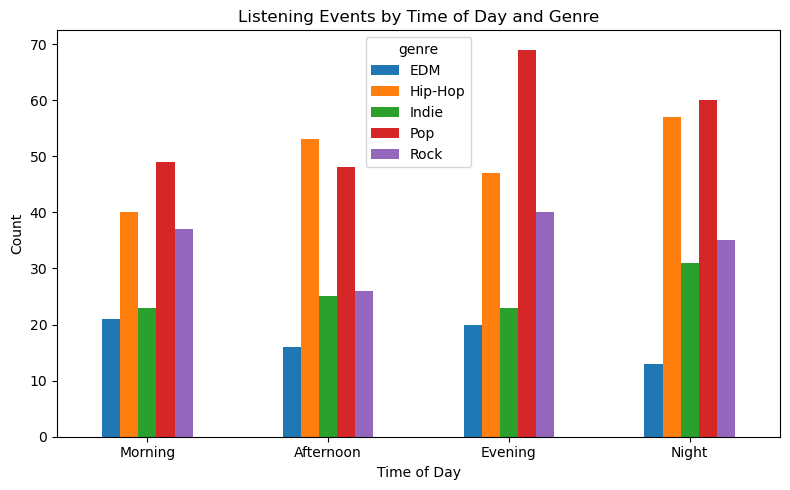

In [18]:
import matplotlib.pyplot as plt

# 1. Group data by time_of_day and genre
time_genre_counts = df.groupby(["time_of_day", "genre"]).size().reset_index(name="count")

# 2. Create a pivot table to show the counts clearly
pivot_table = time_genre_counts.pivot(
    index="time_of_day",
    columns="genre",
    values="count"
)

# Keep time_of_day in a clean order
time_order = ["Morning", "Afternoon", "Evening", "Night"]
pivot_table = pivot_table.reindex(time_order).fillna(0).astype(int)

print(pivot_table)

# 3. Plot a simple chart
pivot_table.plot(kind="bar", figsize=(8, 5))

plt.title("Listening Events by Time of Day and Genre")
plt.xlabel("Time of Day")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 💡 Insight: Pop Dominates Across All Time Periods

Pop consistently has the highest listening counts across all time periods, peaking at **~69 listens in the evening** and remaining strong even at night (~60).

This indicates that Pop acts as a **“default” or universally preferred genre** regardless of context.

### 🎯 Connection to Curated Playlists

Platforms would:
- Always include Pop tracks in playlists  
- Use Pop as a **baseline genre** in mixed playlists  

This ensures playlists feel familiar and widely appealing.

### 💡 Insight: Evening is the Peak Listening Window

Total listening activity is highest during the **evening**, with multiple genres (Pop ~69, Rock ~40, Hip-Hop ~47) showing strong engagement.

This suggests that users are most active and exploratory during this time.

### 🎯 Connection to Curated Playlists

Platforms would:
- Push **high-energy or popular playlists** in the evening  
- Recommend a **mix of genres**, not just one  

This is why “Evening Mix” or “After Work” playlists tend to be more diverse and engaging.

### 💡 Insight: EDM Has Consistently Lower Engagement

EDM shows the lowest listening counts across all time periods (ranging 13–21), with a decline toward night (13).

This indicates that EDM is a **niche or situational preference** rather than a dominant one.

### 🎯 Connection to Curated Playlists

Platforms would:
- Use EDM selectively rather than prominently  
- Include it in **specialized playlists** (e.g., workout or party)

This avoids over-recommending content with lower engagement probability.

### 🧠 Overall Insight: Personalization = Dominance + Context

The data shows two key patterns:

1. **Dominance** → Pop and Hip-Hop drive most listening activity  
2. **Context** → Genre preference shifts based on time of day  

Curated playlists combine both:

- Use dominant genres (Pop, Hip-Hop) for relevance  
- Adjust based on time (e.g., more Hip-Hop at night, diverse mix in evening)

This is why playlists feel both **familiar and context-aware** at the same time.

## 💡 Key Takeaways

- Listening behavior can be used to identify user preferences  
- Genre frequency is a strong indicator of interest  
- Time of day influences music choice  
- Simple analytics can simulate personalized playlists  

## 🏁 Conclusion

This project demonstrates how user listening data can be used to generate personalized playlists.

It highlights how behavior-based analysis enables platforms to deliver relevant and engaging recommendations.